In [1]:
import requests
import pandas as pd
import time
from datetime import datetime

# 1. Configuration
COINS = ['bitcoin', 'ethereum', 'solana', 'cardano', 'dogecoin', 'ripple', 'chainlink']
VS_CURRENCY = 'usd'
DAYS = '365'  # Fetch last 365 days of data
INTERVAL = 'daily'

In [ ]:
# 2. Data Fetching Function
def fetch_crypto_data(coin_id, retries=3, backoff_factor=1.5):
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {
        'vs_currency': VS_CURRENCY,
        'days': DAYS,
        'interval': INTERVAL
    }
    
    for attempt in range(retries):
        try:
            response = requests.get(url, params=params, timeout=15)
            if response.status_code == 429:
                sleep_time = backoff_factor * (2 ** attempt)
                time.sleep(sleep_time)
                continue
            
            response.raise_for_status()
            data = response.json()
            prices = data.get('prices', [])
            if not prices:
                return None
            
            df = pd.DataFrame(prices, columns=['timestamp', 'price'])
            df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
            df['coin'] = coin_id
            return df
        except requests.exceptions.RequestException as e:
            print(f"Connection error on attempt {attempt+1} for {coin_id}: {e}")
            time.sleep(2)
            
    print(f"Failed to fetch data for {coin_id} after {retries} retries.")
    return None

# 3. Execute Fetching
from concurrent.futures import ThreadPoolExecutor

all_data = []
print(f"Starting concurrent data acquisition for {len(COINS)} coins...")

with ThreadPoolExecutor(max_workers=5) as executor:
    results = list(executor.map(fetch_crypto_data, COINS))
    
for df in results:
    if df is not None and not df.empty:
        all_data.append(df)

# 4. Save Data
if all_data:
    final_df = pd.concat(all_data, ignore_index=True)
    final_df.to_csv('crypto_data.csv', index=False)
    print("\nData successfully saved to 'crypto_data.csv'")
    print("Shape of dataset:", final_df.shape)
    print("Unique coins fetched:", final_df['coin'].unique())
else:
    print("No data fetched so far.")


Starting data acquisition...
Fetching data for bitcoin...
Fetching data for ethereum...
Fetching data for solana...
Fetching data for cardano...
Fetching data for dogecoin...
Fetching data for ripple...
Error fetching data for ripple: 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/ripple/market_chart?vs_currency=usd&days=365&interval=daily
Fetching data for polkadot...
Error fetching data for polkadot: 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/polkadot/market_chart?vs_currency=usd&days=365&interval=daily
Fetching data for chainlink...
Error fetching data for chainlink: 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/chainlink/market_chart?vs_currency=usd&days=365&interval=daily
Fetching data for litecoin...
Error fetching data for litecoin: 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/litecoin/market_chart?vs_currency=usd&days=365&int

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_theme(style="darkgrid")

# 1. Load Data (Simulating a fresh start for Milestone 2)
try:
    df = pd.read_csv('crypto_data.csv')
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    print("Data loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: 'crypto_data.csv' check if fetch step ran correctly.")

Data loaded successfully.


,timestamp,price,coin
0,2025-02-21,98384.317382,bitcoin
1,2025-02-22,96135.155413,bitcoin
2,2025-02-23,96564.154143,bitcoin
3,2025-02-24,96327.463091,bitcoin
4,2025-02-25,91396.766869,bitcoin


In [4]:
# 2. Data Processing: Missing Values & Duplicates

# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values Report:\n", missing_values[missing_values > 0])

# Drop duplicates if any
initial_len = len(df)
df.drop_duplicates(inplace=True)
print(f"\nDuplicates Removed: {initial_len - len(df)}")

# Ensure consistent data types
print("\nData Types:\n", df.dtypes)

Missing Values Report:
 Series([], dtype: int64)

Duplicates Removed: 0

Data Types:
 timestamp    datetime64[ns]
price               float64
coin                 object
dtype: object


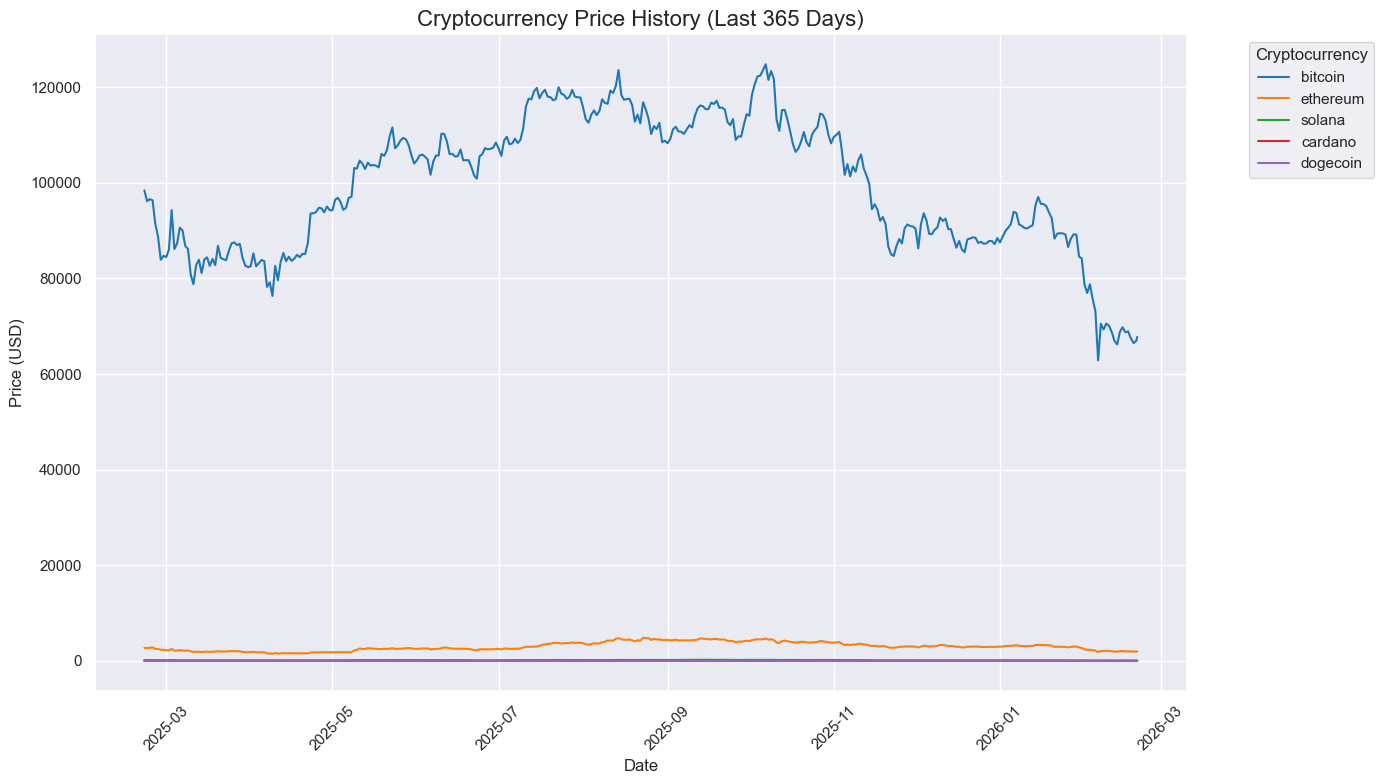

In [5]:
plt.figure(figsize=(14, 8))
sns.lineplot(data=df, x='timestamp', y='price', hue='coin', palette='tab10')

plt.title('Cryptocurrency Price History (Last 365 Days)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(title='Cryptocurrency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 4. Interactive Dashboard
The following code creates a Streamlit dashboard (`app.py`) to visualize the data interactively.

In [6]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import numpy as np
import scipy.stats as stats
import hashlib
from groq import Groq
import os
try:
    from dotenv import load_dotenv
    # Use absolute path to ensure .env is found in the script's directory
    env_path = os.path.join(os.path.dirname(__file__), '.env')
    load_dotenv(env_path)
    
    # Configure Groq once at startup
    api_key = os.getenv('GROQ_API_KEY')
    grok_client = None
    if api_key:
        grok_client = Groq(api_key=api_key)
except ImportError:
    grok_client = None
    pass
import time
import requests
from concurrent.futures import ThreadPoolExecutor

# --- 1. Page Configuration ---
st.set_page_config(
    page_title="Crypto Volatility and Risk Analyzer - Milestone 3",
    page_icon="💠",
    layout="wide",
    initial_sidebar_state="expanded"
)

# --- 2. Advanced Custom CSS ---
st.markdown("""
<style>
    /* Main Background */
    .stApp {
        background-color: #0E1117;
        color: #FAFAFA;
        font-family: 'Inter', sans-serif;
    }

    /* Sidebar Styling */
    section[data-testid="stSidebar"] {
        background-color: #0d1117; 
        border-right: 1px solid #30363D;
        padding-top: 20px;
    }
    
    /* --- SIDEBAR VISIBILITY FIXES (CRITICAL v2) --- */
    
    /* Force ALL basic text in sidebar to be white */
    section[data-testid="stSidebar"] p, 
    section[data-testid="stSidebar"] span, 
    section[data-testid="stSidebar"] label,
    section[data-testid="stSidebar"] h1,
    section[data-testid="stSidebar"] h2,
    section[data-testid="stSidebar"] h3,
    section[data-testid="stSidebar"] h4 {
        color: #E6EDF3 !important;
    }
    
    /* 1. SELECT BOX (Closed State - "Select Asset") */
    /* This targets the container of the closed dropdown */
    div[data-baseweb="select"] > div {
        background-color: #0D1117 !important; /* Dark Background */
        color: #E6EDF3 !important;            /* White Text */
        border-color: #30363D !important;     /* Grey Border */
    }
    /* This targets the text inside */
    div[data-baseweb="select"] span {
        color: #E6EDF3 !important;
    }
    /* The arrow icon */
    div[data-baseweb="select"] svg {
        fill: #E6EDF3 !important; 
    }
    
    /* 2. EXPANDER HEADER ("Ask Cortex...") */
    /* Targets the summary/header of the expander */
    div[data-testid="stExpander"] details > summary {
        background-color: #161B22 !important; /* Dark Background */
        color: #E6EDF3 !important;            /* White Text */
        border: 1px solid #30363D !important;
        border-radius: 6px;
    }
    div[data-testid="stExpander"] details > summary:hover {
        background-color: #1F2937 !important; /* Slightly lighter on hover */
        color: #58A6FF !important;            /* Blue Text on Hover */
    }
    /* The arrow icon in expander */
    div[data-testid="stExpander"] details > summary svg {
        fill: #E6EDF3 !important;
    }
    
    /* 3. RADIO BUTTONS & CHECKBOXES */
    .stRadio div[role='radiogroup'] > label > div:first-child + div {
        color: #E6EDF3 !important;
    }
    .stCheckbox label span {
        color: #E6EDF3 !important;
    }
    
    /* 4. TEXT INPUT ("Query Market Data") */
    div[data-baseweb="input"] > div {
        background-color: #0D1117 !important;
        color: #E6EDF3 !important;
        border-color: #30363D !important; 
    }
    input[data-baseweb="input"] {
        color: #E6EDF3 !important;
    }
    
    /* Top Label of widgets ("Select Asset", "Timeframe") */
    div[data-testid="stWidgetLabel"] p {
        color: #9CA3AF !important; 
        font-weight: 600;
    }
    
    /* Dropdown Menu Items (The list that pops up) */
    ul[data-testid="stSelectboxVirtualDropdown"] li {
        background-color: #1F2937 !important;
        color: #E6EDF3 !important;
    }
    ul[data-testid="stSelectboxVirtualDropdown"] li:hover {
        background-color: #58A6FF !important;
        color: #FFFFFF !important;
    }
    
    /* Tabs Styling */
    button[data-baseweb="tab"] {
        color: #8B949E;
        font-weight: 600;
        font-size: 14px;
        padding: 10px 20px;
        background-color: transparent;
        border: none;
    }
    button[data-baseweb="tab"]:hover {
        color: #58A6FF;
        background-color: rgba(88, 166, 255, 0.1);
    }
    button[data-baseweb="tab"][aria-selected="true"] {
        color: #58A6FF !important;
        background-color: #1F2937;
        border-radius: 8px 8px 0 0;
        border-bottom: 2px solid #58A6FF;
    }
    
    /* Custom Metric Cards */
    div.metric-card {
        background: linear-gradient(145deg, #1f2937, #111827);
        border: 1px solid #374151;
        border-radius: 12px;
        padding: 16px;
        box-shadow: 0 4px 6px rgba(0, 0, 0, 0.3);
        padding: 16px;
        box-shadow: 0 4px 6px rgba(0, 0, 0, 0.3);
        margin-bottom: 16px;
        min-height: 120px;
        display: flex;
        flex-direction: column;
        justify-content: center;
    }
    div.metric-label {
        color: #9CA3AF;
        font-size: 0.75rem;
        font-weight: 600;
        text-transform: uppercase;
        letter-spacing: 0.05em;
        margin-bottom: 4px;
    }
    div.metric-value {
        color: #F9FAFB;
        font-size: 1.5rem;
        font-weight: 800;
        font-family: 'Roboto Mono', monospace;
    }
    .positive { color: #34D399; font-weight: 600; font-size: 0.9rem;}
    .negative { color: #F87171; font-weight: 600; font-size: 0.9rem;}
    
    /* Risk Table Styling */
    .risk-table {
        font-family: 'Segoe UI', sans-serif;
        width: 100%;
        border-collapse: collapse;
        margin-bottom: 20px;
        background-color: #161B22;
        border-radius: 8px;
        overflow: hidden;
    }
    .risk-table th {
        text-align: left;
        color: #8B949E;
        padding: 16px;
        border-bottom: 1px solid #30363D;
        font-size: 14px;
        text-transform: uppercase;
        background-color: #0d1117;
    }
    .risk-table td {
        padding: 16px;
        border-bottom: 1px solid #21262D;
        color: #E6EDF3;
        font-size: 15px;
    }
    .risk-table tr:last-child td {
        border-bottom: none;
    }
    
    /* Chart Container */
    .chart-box {
        background-color: #161B22;
        border: 1px solid #30363D;
        border-radius: 12px;
        padding: 15px;
        box-shadow: 0 4px 6px rgba(0,0,0,0.2);
        margin-bottom: 20px;
    }
    
    /* AI Chat Box */
    .ai-box {
        background-color: #0D1117;
        border: 1px solid #30363D;
        border-radius: 8px;
        padding: 15px;
        font-size: 13px;
        color: #E6EDF3;
        margin-top: 10px;
        border-left: 3px solid #58A6FF;
    }
    
    /* Refresh Button Styling */
    div.stButton > button {
        background-color: #238636;
        color: white;
        border: 1px solid rgba(240, 246, 252, 0.1);
        border-radius: 6px;
        font-weight: 600;
        transition: all 0.2s ease-in-out;
    }
    div.stButton > button:hover {
        background-color: #2ea043;
        border-color: #8b949e;
        transform: scale(1.02);
        color: #ffffff;
    }
</style>
""", unsafe_allow_html=True)

# --- 3. Data Engine ---
COINS = ['bitcoin', 'ethereum', 'solana', 'cardano', 'dogecoin', 'ripple', 'chainlink']
VS_CURRENCY = 'usd'
DAYS = '365'
INTERVAL = 'daily'

def fetch_crypto_data(coin_id, retries=3, backoff_factor=1.5):
    """Fetch historical market data for a single coin from CoinGecko API with retry logic."""
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {
        'vs_currency': VS_CURRENCY,
        'days': DAYS,
        'interval': INTERVAL
    }
    
    for attempt in range(retries):
        try:
            response = requests.get(url, params=params, timeout=15)
            # If 429 Too Many Requests, wait and retry
            if response.status_code == 429:
                sleep_time = backoff_factor * (2 ** attempt)
                time.sleep(sleep_time)
                continue
                
            response.raise_for_status()
            data = response.json()
            prices = data.get('prices', [])
            
            if not prices:
                return None
                
            df = pd.DataFrame(prices, columns=['timestamp', 'price'])
            df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
            df['coin'] = coin_id
            return df
            
        except requests.exceptions.RequestException:
            # On generic connection error, take a short pause and try again
            time.sleep(2)
            
    # Return None if all retries failed
    return None

@st.cache_data(show_spinner=False)
def load_data():
    """Load crypto data from local CSV (fast). Use refresh to fetch live data."""
    csv_path = os.path.join(os.path.dirname(__file__), 'crypto_data.csv')
    try:
        df = pd.read_csv(csv_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        return df
    except FileNotFoundError:
        return pd.DataFrame()

def refresh_data_from_api():
    """Fetch fresh data from CoinGecko API concurrently and save to CSV."""
    csv_path = os.path.join(os.path.dirname(__file__), 'crypto_data.csv')
    all_data = []
    
    with ThreadPoolExecutor(max_workers=5) as executor:
        results = list(executor.map(fetch_crypto_data, COINS))
        
    for df in results:
        if df is not None and not df.empty:
            all_data.append(df)
    
    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        final_df.to_csv(csv_path, index=False)
        return True
    return False


@st.cache_data(show_spinner=False, ttl=600)
def get_nexus_ai_response(query, _df, current_coin):
    """Enhanced Cortex AI with caching for speed."""
    df = _df # Use underscore to prevent streamlit from hashing the whole dataframe
    query = query.lower()
    
    # Identify target coin
    all_coins = df['coin'].unique()
    target_coin = current_coin
    for c in all_coins:
        if c in query:
            target_coin = c
            break
            
    # fetch data
    coin_data = df[df['coin'] == target_coin].sort_values('timestamp').copy()
    latest = coin_data.iloc[-1]
    curr_price = latest['price']
    
    # Basic technicals for AI context
    rets = coin_data['price'].pct_change()
    vol = rets.rolling(30).std().iloc[-1] * np.sqrt(365) * 100
    sma20 = coin_data['price'].rolling(20).mean().iloc[-1]
    
    # RSI calculation for AI
    delta = coin_data['price'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs)).iloc[-1]
    
    # Bollinger Bands for AI
    std20 = coin_data['price'].rolling(20).std().iloc[-1]
    upper_b = sma20 + (std20 * 2)
    lower_b = sma20 - (std20 * 2)

    # --- HYBRID LLM LOGIC (PRIORITY) ---
    if grok_client:
        try:
            context = f"""
            You are 'Cortex', an Advanced Crypto Analysis AI. 
            User is looking at {target_coin.upper()}.
            
            REAL-TIME DATA:
            - Price: ${curr_price:,.2f}
            - 20-Day Avg: ${sma20:,.2f}
            - RSI (14): {rsi:.1f}
            - Annual Volatility: {vol:.1f}%
            - Support Level: ${lower_b:,.2f}
            - Resistance Level: ${upper_b:,.2f}
            
            INSTRUCTIONS:
            1. Use the provided technical data to answer.
            2. Be conversational but professional.
            3. If asked for a suggestion or 'should I invest', provide a balanced technical perspective (e.g. "Technically, the RSI suggests interest...") but include a CLEAR financial disclaimer.
            4. Keep the response concise for a dashboard sidebar.
            """
            
            completion = grok_client.chat.completions.create(
                model="llama-3.1-8b-instant", # Updated, supported fast Llama model on Groq
                messages=[
                    {"role": "system", "content": context},
                    {"role": "user", "content": query}
                ]
            )
            return completion.choices[0].message.content
        except Exception as e:
            # If it's a quota/API error, we fall back silently or with a friendly note
            if "429" in str(e) or "quota" in str(e).lower():
                pass # Continue to heuristic fallback
            else:
                return f"**[Groq Error]** {str(e)}"

    # --- HEURISTIC FALLBACK ---
    if any(k in query for k in ["price", "cost", "value"]):
        return f"The current price of **{target_coin.upper()}** is **${curr_price:,.2f}**. It is currently trading {'above' if curr_price > sma20 else 'below'} its 20-day average."
    
    elif any(k in query for k in ["high", "peak", "max"]):
        high_all = coin_data['price'].max()
        return f"The record high for **{target_coin.upper()}** in my current records is **${high_all:,.2f}**."
    
    elif any(k in query for k in ["low", "bottom", "min"]):
        low_all = coin_data['price'].min()
        return f"The record low for **{target_coin.upper()}** in my current records is **${low_all:,.2f}**."
    
    elif any(k in query for k in ["volatility", "risk", "sharpe"]):
        risk_level = "High 🔥" if vol > 60 else "Moderate ⚖️" if vol > 30 else "Low 🛡️"
        return (f"**{target_coin.upper()}** has an annualized volatility of **{vol:.1f}%**. "
                f"Current Risk Profile: **{risk_level}**. Support levels are around **${lower_b:,.2f}**.")
    
    elif any(k in query for k in ["rsi", "momentum", "strength"]):
        sentiment = "Overbought (Caution)" if rsi > 70 else "Oversold (Interest)" if rsi < 30 else "Neutral"
        return f"The RSI for **{target_coin.upper()}** is **{rsi:.1f}**, currently in **{sentiment}** territory."
    
    elif any(k in query for k in ["trend", "bull", "bear", "predict"]):
        trend = "Bullish 📈" if curr_price > sma20 else "Bearish 📉"
        action = "testing resistance" if curr_price > upper_b else "finding support" if curr_price < lower_b else "consolidating"
        return f"The current trend for **{target_coin.upper()}** is **{trend}**. The asset is currently {action}."

    elif "buy" in query or "sell" in query:
        return ("As an AI, I can't give financial advice, but looking at technicals: "
                f"**{target_coin.upper()}** has an RSI of **{rsi:.1f}** and is trading at **${curr_price:,.2f}**. "
                "Always perform your own due diligence!")
    
    else:
        return (f"I am monitoring **{target_coin.upper()}**. You can ask me about its **Price**, **Volatility**, "
                "**RSI Momentum**, **Trend Analysis**, or **High/Low** benchmarks.")

def calculate_risk_profile(df, days_str):
    end_date = df['timestamp'].max()
    days_map = {"30D": 30, "90D": 90, "1Y": 365}
    start_date = end_date - timedelta(days=days_map.get(days_str, 90))
    df_filtered = df[df['timestamp'] >= start_date].copy()
    
    df_pivot = df_filtered.pivot(index='timestamp', columns='coin', values='price')
    returns = df_pivot.pct_change().dropna()
    
    if 'bitcoin' in returns.columns:
        benchmark = returns['bitcoin']
    else:
        benchmark = returns.mean(axis=1)
    
    metrics = []
    for coin in returns.columns:
        coin_rets = returns[coin]
        vol = coin_rets.std() * np.sqrt(365) * 100
        ann_ret = coin_rets.mean() * 365 * 100
        excess_ret = coin_rets.mean() * 365 - 0.02
        sharpe = excess_ret / (vol/100) if vol != 0 else 0
        cov = np.cov(coin_rets, benchmark)[0][1]
        var = np.var(benchmark)
        beta = cov / var if var != 0 else 0
        var_95 = np.percentile(coin_rets, 5) * 100
        metrics.append({
            "Crypto": coin.upper(),
            "Volatility": vol,
            "Return": ann_ret,
            "Sharpe": sharpe,
            "Beta": beta,
            "VaR (95%)": var_95
        })
    return pd.DataFrame(metrics).sort_values("Volatility", ascending=True)

def process_single_asset(df, coin, days):
    df_coin = df[df['coin'] == coin].sort_values('timestamp').reset_index(drop=True)
    
    # Check if we have data for this coin
    if df_coin.empty or pd.isna(df_coin['timestamp'].max()):
        return df_coin
        
    start_date = None
    end_date = None
    
    if isinstance(days, tuple) and len(days) == 2:
        start_date = pd.to_datetime(days[0])
        # Include the entire end day
        end_date = pd.to_datetime(days[1]) + pd.Timedelta(hours=23, minutes=59, seconds=59)
    elif isinstance(days, tuple) and len(days) == 1:
        start_date = pd.to_datetime(days[0])
        end_date = start_date + pd.Timedelta(hours=23, minutes=59, seconds=59)
    elif hasattr(days, 'strftime'):
        start_date = pd.to_datetime(days)
        end_date = start_date + pd.Timedelta(hours=23, minutes=59, seconds=59)
    elif isinstance(days, str): # fallback
        end_date = df_coin['timestamp'].max()
        if days != "ALL":
            days_map = {"1W": 7, "1M": 30, "3M": 90, "6M": 180, "1Y": 365, "YTD": (end_date - datetime(int(end_date.year), 1, 1)).days}
            start_date = end_date - timedelta(days=days_map.get(days, 365))
        else:
            start_date = df_coin['timestamp'].min()
            
    if start_date is not None and end_date is not None:
        df_coin = df_coin[(df_coin['timestamp'] >= start_date) & (df_coin['timestamp'] <= end_date)].copy()
    
    # Indicators
    df_coin['SMA_20'] = df_coin['price'].rolling(window=20).mean()
    df_coin['EMA_50'] = df_coin['price'].ewm(span=50, adjust=False).mean()
    df_coin['STD_20'] = df_coin['price'].rolling(window=20).std()
    df_coin['BB_Upper'] = df_coin['SMA_20'] + (df_coin['STD_20'] * 2)
    df_coin['BB_Lower'] = df_coin['SMA_20'] - (df_coin['STD_20'] * 2)
    
    delta = df_coin['price'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_coin['RSI'] = 100 - (100 / (1 + rs))
    
    # MACD
    exp1 = df_coin['price'].ewm(span=12, adjust=False).mean()
    exp2 = df_coin['price'].ewm(span=26, adjust=False).mean()
    df_coin['MACD'] = exp1 - exp2
    df_coin['Signal'] = df_coin['MACD'].ewm(span=9, adjust=False).mean()
    
    # Volatility
    df_coin['Returns'] = df_coin['price'].pct_change()
    df_coin['Volatility'] = df_coin['Returns'].rolling(window=30).std() * np.sqrt(365) * 100
    
    # Sharpe Ratio (Approximate for the timeframe)
    ann_ret = df_coin['Returns'].mean() * 365
    ann_vol = df_coin['Returns'].std() * np.sqrt(365)
    df_coin['Sharpe'] = (ann_ret - 0.02) / ann_vol if ann_vol > 0 else 0
    
    return df_coin



# --- 4. Sidebar Controls ---
# --- 3.5 Authentication System ---
USER_DB_FILE = os.path.join(os.path.dirname(__file__), 'users.csv')

def init_user_db():
    if not os.path.exists(USER_DB_FILE):
        df = pd.DataFrame(columns=['username', 'password', 'created_at'])
        df.to_csv(USER_DB_FILE, index=False)

def hash_password(password):
    return hashlib.sha256(str.encode(password)).hexdigest()

def verify_user(username, password):
    init_user_db()
    try:
        df = pd.read_csv(USER_DB_FILE)
        if username in df['username'].values:
            user_row = df[df['username'] == username].iloc[0]
            if user_row['password'] == hash_password(password):
                return True
    except Exception as e:
        st.error(f"Auth Error: {e}")
    return False

def register_user(username, password):
    init_user_db()
    try:
        df = pd.read_csv(USER_DB_FILE)
        if username in df['username'].values:
            return False, "Username already exists."
        
        new_user = pd.DataFrame({
            'username': [username],
            'password': [hash_password(password)],
            'created_at': [datetime.now().isoformat()]
        })
        df = pd.concat([df, new_user], ignore_index=True)
        df.to_csv(USER_DB_FILE, index=False)
        return True, "User registered successfully!"
    except Exception as e:
        return False, f"Registration failed: {e}"

def login_register_page():
    # --- PREMIUM LOGIN UI DESIGN ---
    st.markdown("""
    <style>
        /* Import Premium Fonts */
        @import url('https://fonts.googleapis.com/css2?family=Outfit:wght@300;400;600;700;800;900&family=Inter:wght@300;400;500;600;700&display=swap');

        /* --- GLOBAL RESET --- */
        .stApp {
            background: transparent !important;
        }
        
        [data-testid="stAppViewContainer"] {
            background: 
                linear-gradient(rgba(10, 15, 30, 0.45) 0%, rgba(10, 15, 30, 0.65) 100%),
                url("...") !important;
            background-size: cover !important;
            background-position: center !important;
            background-attachment: fixed !important;
        }

        [data-testid="stAppViewContainer"]::before {
            content: "";
            position: fixed;
            top: 0; left: 0; width: 100%; height: 100%;
            background-image: 
                linear-gradient(rgba(255, 255, 255, 0.04) 1px, transparent 1px),
                linear-gradient(90deg, rgba(255, 255, 255, 0.04) 1px, transparent 1px);
            background-size: 50px 50px;
            pointer-events: none;
            z-index: 0;
        }

        [data-testid="stHeader"], [data-testid="stFooter"] {
            display: none !important;
        }

        /* --- CARD DESIGN --- */
        [data-testid="stForm"] {
            background: rgba(15, 22, 40, 0.5) !important;
            backdrop-filter: blur(30px) saturate(210%);
            -webkit-backdrop-filter: blur(30px) saturate(210%);
            border: 1px solid rgba(255, 255, 255, 0.15);
            border-radius: 35px;
            padding: 45px !important;
            box-shadow: 
                0 35px 70px -15px rgba(0, 0, 0, 0.7),
                inset 0 0 0 1px rgba(255, 255, 255, 0.1);
        }

        /* --- TITLES (BOLD & CLEAR) --- */
        .login-title {
            font-family: 'Outfit', sans-serif;
            font-size: 68px;
            font-weight: 900;
            text-align: center;
            background: linear-gradient(135deg, #FFFFFF 40%, #CBD5E1 100%);
            -webkit-background-clip: text;
            -webkit-text-fill-color: transparent;
            margin-bottom: 5px;
            filter: drop-shadow(0 10px 15px rgba(0,0,0,0.6));
            letter-spacing: -0.04em;
        }
        
        .login-subtitle {
            font-family: 'Inter', sans-serif;
            font-size: 16px;
            color: #F1F5F9;
            text-align: center;
            margin-bottom: 35px;
            letter-spacing: 0.3em;
            text-transform: uppercase;
            font-weight: 700;
            text-shadow: 0 4px 8px rgba(0,0,0,0.5);
        }

        /* Card Header */
        [data-testid="stForm"] h3 {
            color: white !important;
            font-weight: 800 !important;
            font-size: 32px !important;
            text-shadow: 0 2px 4px rgba(0,0,0,0.3);
        }

        /* --- LABELS (BOLD & CLEAR) --- */
        [data-testid="stForm"] label p {
            color: #FFFFFF !important;
            font-weight: 700 !important;
            font-size: 16px !important;
            text-shadow: 0 1px 3px rgba(0,0,0,0.8);
            margin-bottom: 4px !important;
        }

        /* Inputs */
        div[data-baseweb="input"] > div {
            background-color: rgba(5, 8, 15, 0.8) !important;
            border: 1px solid rgba(255, 255, 255, 0.15) !important;
            border-radius: 18px !important;
        }
        
        div[data-baseweb="input"] input {
            color: white !important;
            font-weight: 500 !important;
        }

        /* Buttons */
        div[data-testid="stForm"] button {
            background: linear-gradient(135deg, #3B82F6 0%, #172554 100%);
            border: 1px solid rgba(255, 255, 255, 0.2);
            padding: 18px 0 !important;
            border-radius: 18px;
            font-weight: 800;
            font-size: 18px;
            letter-spacing: 2.5px;
            box-shadow: 0 12px 24px -6px rgba(59, 130, 246, 0.5);
        }
        
        div[data-testid="stForm"] button:hover {
            transform: translateY(-3px);
            filter: brightness(1.25);
            box-shadow: 0 20px 35px -8px rgba(59, 130, 246, 0.6);
        }

        /* Bottom Toggle Text (BOLD & CLEAR) */
        .toggle-text {
            text-align: center;
            color: #F8FAFC;
            margin-top: 35px;
            font-size: 15px;
            font-weight: 600;
            text-shadow: 0 2px 4px rgba(0,0,0,0.5);
        }

        div.stButton button {
            background: rgba(255, 255, 255, 0.08);
            border: 1px solid rgba(255, 255, 255, 0.2);
            border-radius: 18px;
            color: white;
            font-weight: 700;
            letter-spacing: 0.5px;
        }
        
        div.stButton button:hover {
            background: rgba(255, 255, 255, 0.18);
            border-color: rgba(255, 255, 255, 0.4);
        }
    </style>
""", unsafe_allow_html=True)

    # --- LAYOUT MANAGEMENT ---
    col1, col2, col3 = st.columns([1, 1.2, 1])

    with col2:
        st.markdown('<div class="login-title">Crypto Analyzer Pro</div>', unsafe_allow_html=True)
        st.markdown('<div class="login-subtitle">Milestone 3 • Advanced Risk Analytics</div>', unsafe_allow_html=True)
        
        if "auth_mode" not in st.session_state:
            st.session_state.auth_mode = "login"

        def toggle():
            st.session_state.auth_mode = (
                "register" if st.session_state.auth_mode == "login" else "login"
            )

        if st.session_state.auth_mode == "login":
            with st.form("login_form"):
                st.markdown("<h3 style='text-align: center; color: white; margin-bottom: 20px;'>Welcome Back</h3>", unsafe_allow_html=True)
                user = st.text_input("Email", placeholder="name@example.com")
                pwd = st.text_input("Password", placeholder="••••••••", type="password")
                
                st.markdown("<br>", unsafe_allow_html=True)
                
                # Check for cached messages
                if "login_error" in st.session_state:
                     st.error(st.session_state.login_error)
                     del st.session_state.login_error

                submit = st.form_submit_button("Sign In")
                
                if submit:
                    if verify_user(user, pwd):
                        st.session_state.authenticated = True
                        st.session_state.username = user
                        st.rerun()
                    else:
                        st.session_state.login_error = "Invalid credentials"
                        st.rerun()

            st.markdown('<div class="toggle-text">New User?</div>', unsafe_allow_html=True)
            if st.button("Create Account", use_container_width=True):
                toggle()
                st.rerun()

        else:
            with st.form("register_form"):
                st.markdown("<h3 style='text-align: center; color: white; margin-bottom: 20px;'>Create Account</h3>", unsafe_allow_html=True)
                new_u = st.text_input("Username", placeholder="Choose a username")
                new_p = st.text_input("Password", placeholder="••••••••", type="password")
                conf = st.text_input("Confirm Password", placeholder="••••••••", type="password")
                
                st.markdown("<br>", unsafe_allow_html=True)

                if "reg_error" in st.session_state:
                     st.error(st.session_state.reg_error)
                     del st.session_state.reg_error
                
                submit = st.form_submit_button("Sign Up")
                
                if submit:
                    if new_p == conf:
                        ok, msg = register_user(new_u, new_p)
                        if ok:
                            st.success("Account created! Please sign in.")
                            time.sleep(1)
                            toggle()
                            st.rerun()
                        else:
                            st.session_state.reg_error = msg
                            st.rerun()
                    else:
                        st.session_state.reg_error = "Passwords do not match"
                        st.rerun()

            st.markdown('<div class="toggle-text">Already have an account?</div>', unsafe_allow_html=True)
            if st.button("Back to Login", use_container_width=True):
                toggle()
                st.rerun()



# Initialization
if 'authenticated' not in st.session_state:
    st.session_state['authenticated'] = False

if not st.session_state['authenticated']:
    login_register_page()
    st.stop()

# --- 4. Sidebar Controls ---
raw_df = load_data()

# --- Top Bar Controls ---
t1, t2 = st.columns([8, 1])
with t2:
    if st.button("🔄 Refresh"):
        with st.spinner("⏳ Fetching live crypto data..."):
            refresh_data_from_api()
        load_data.clear()
        try:
            st.rerun()
        except AttributeError:
            st.experimental_rerun()

if raw_df.empty:
    st.error("Failed to fetch data from API and no local backup found. Please check your internet connection and try again.")
    st.stop()


with st.sidebar:
    st.title("Crypto Analyzer M3")
    
    
    # User Profile
    st.markdown(f"""
    <div style='background: #161b22; padding: 10px; border-radius: 8px; border: 1px solid #30363d; margin-bottom: 20px;'>
        <div style='color: #8b949e; font-size: 12px;'>Logged in as:</div>
        <div style='color: #58a6ff; font-weight: 600;'>@{st.session_state.get('username', 'User')}</div>
    </div>
    """, unsafe_allow_html=True)
    
    if st.button("🚪 Logout", key="logout_btn", use_container_width=True):
        st.session_state['authenticated'] = False
        st.session_state['username'] = None
        st.rerun()

    st.markdown("---")
    
    st.subheader("🖥️ DASHBOARD MODE")
    view_mode = st.radio("Select View", ["📈 Individual Asset", "⚖️ Risk Comparison"], index=0)
    
    st.markdown("---")
    
    default_coin = "bitcoin" 
    
    if view_mode == "📈 Individual Asset":
        st.subheader("ASSET CONTROLS")
        coins = sorted(COINS)
        selected_coins = st.sidebar.multiselect("Select Assets", coins, default=["bitcoin"])
        
        if not selected_coins:
            st.warning("Please select at least one asset.")
            st.stop()
            
        # Check if we have data for the primary selected coin
        if selected_coins[0] not in raw_df['coin'].unique():
            st.info(f"💡 Data for **{selected_coins[0].upper()}** is not yet cached. Please click the **🔄 Refresh** button top-right to fetch live data.")
            st.stop()

        selected_coin = selected_coins[0]
        default_coin = selected_coin 
        
        # Calendar Timeframe Input
        min_date = raw_df['timestamp'].min().date() if not raw_df.empty else datetime.today().date()
        max_date = raw_df['timestamp'].max().date() if not raw_df.empty else datetime.today().date()
        default_start = max_date - timedelta(days=365)
        if default_start < min_date:
            default_start = min_date
            
        time_range = st.date_input(
            "Timeframe Range", 
            value=(default_start, max_date),
            min_value=min_date, 
            max_value=max_date
        )
        
        # Wait until the user selects BOTH start and end dates
        if isinstance(time_range, tuple) and len(time_range) == 1:
            st.info("📅 Please select an end date on the calendar.")
            st.stop()
        
        st.markdown("---")
        st.subheader("INDICATORS")
        show_ma = st.checkbox("MA Ribbons", value=True)
        show_bb = st.checkbox("Bollinger Bands", value=True)
        show_macd = st.checkbox("MACD Oscillator", value=False)
        chart_style = st.radio("Chart Type", ["Line", "Area", "Candles"], index=1)
        
    else:
        st.subheader("RISK PARAMETERS")
        risk_timeframe = st.radio("Calculation Period", ["30D", "90D", "1Y"], horizontal=True, index=1)
        st.info("Comparing all assets against Bitcoin benchmark.")
        selected_coin = "bitcoin" # Fallback

    # --- NEXUS AI INTEGRATION ---
    st.markdown("---")
    st.subheader("🤖Crypto AI")
    with st.expander("Ask Cortex...", expanded=True):
        ai_query = st.text_input("Query Market Data:", placeholder="e.g. Price of Bitcoin?")
        if ai_query:
            with st.spinner("Cortex is analyzing..."):
                response = get_nexus_ai_response(ai_query, raw_df, default_coin)
            st.markdown(f"<div class='ai-box'><b>CORTEX:</b><br>{response}</div>", unsafe_allow_html=True)
        else:
            st.markdown("<div style='font-size: 12px; color: #9CA3AF;'>Ask about Prices, Volatility, or Trends.</div>", unsafe_allow_html=True)
        
        # Connection Status
        api_key_check = os.getenv('GROQ_API_KEY')
        if grok_client and api_key_check:
            key_status = "Connected to Groq ⚡"
            key_hint = f" (Starts with: {api_key_check[:4]}...)"
        else:
            key_status = "Heuristic Mode 💤"
            key_hint = " (No GROQ_API_KEY found)"
            
        st.markdown(f"<div style='font-size: 10px; color: #6B7280; margin-top: 10px; text-align: center;'>Engine: {key_status}{key_hint}</div>", unsafe_allow_html=True)


# --- 5. Main Dashboard Logic ---

# Helper for Metric Cards
def render_card(label, value, delta=None, is_currency=False):
    if delta is not None:
        delta_cls = "positive" if delta >= 0 else "negative"
        delta_sign = "+" if delta >= 0 else ""
        delta_html = f'<div class="metric-delta {delta_cls}">{delta_sign}{delta:.2f}%</div>'
    else:
        delta_html = f'<div class="metric-delta" style="visibility:hidden">0.00%</div>'
    val_str = f"${value:,.2f}" if is_currency else f"{value:,.2f}"
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-label">{label}</div>
        <div class="metric-value">{val_str}</div>
        {delta_html}
    </div>
    """, unsafe_allow_html=True)

if view_mode == "📈 Individual Asset":
    df = process_single_asset(raw_df, selected_coin, time_range)
    
    if df is None or len(df) < 2:
        st.warning("Not enough data to display. Please select a wider timeframe.")
        st.stop()
        
    latest = df.iloc[-1]
    prev = df.iloc[-2]
    
    # 1. Header
    c1, c2 = st.columns([2,1])
    with c1:
        st.markdown(f"<h1 style='font-size: 2.2rem; margin-bottom: 0;'>{selected_coin.upper()} <span style='color: #6B7280; font-size: 1.5rem; font-weight: 400;'>USD</span></h1>", unsafe_allow_html=True)
        st.markdown(f"<p style='color: #9CA3AF; margin-top: -5px; font-size: 0.9rem;'>High-Frequency Market Data • {latest['timestamp'].strftime('%d %b %Y %H:%M:%S UTC')}</p>", unsafe_allow_html=True)
    
    with c2:
        price_change = latest['price'] - prev['price']
        pct_change = (price_change / prev['price']) * 100
        color = "#34D399" if pct_change >= 0 else "#F87171"
        arrow = "▲" if pct_change >= 0 else "▼"
        st.markdown(f"""
        <div style="text-align: right; background: rgba(31, 41, 55, 0.6); padding: 15px; border-radius: 12px; border: 1px solid #374151;">
            <div style="font-size: 24px; font-weight: 800; color: #F9FAFB; letter-spacing: -1px;">${latest['price']:,.2f}</div>
            <div style="font-size: 14px; font-weight: 600; color: {color}; margin-top: 5px;">
                {arrow} {abs(price_change):.2f} ({pct_change:+.2f}%)
            </div>
        </div>
        """, unsafe_allow_html=True)
    
    st.markdown("<br>", unsafe_allow_html=True)
    
    # 2. Metric Cards
    m1, m2, m3, m4, m5 = st.columns(5)
    with m1: render_card("24h High", df[-7:]['price'].max(), is_currency=True)
    with m2: render_card("24h Low", df[-7:]['price'].min(), is_currency=True)
    with m3: render_card("Volatility (Ann.)", latest['Volatility'], delta=latest['Volatility'] - prev['Volatility'])
    with m4: render_card("Sharpe Ratio", latest.get('Sharpe', 0.0))
    with m5: render_card("RSI Strength", latest['RSI'], delta=latest['RSI'] - prev['RSI'])
    
    st.markdown("<br>", unsafe_allow_html=True)
    
    # 3. Tabs
    tabs = st.tabs(["📉 PRICE & VOLATILITY TREND", "📊 ANALYTICAL DEPTH", "📋 HISTORICAL DATA"])
    
    with tabs[0]:
        # --- SEPARATE GRAPHS ---
        
        # 1. Price Trend Graph
        st.markdown("### 📉 Price Trend")
        st.markdown("<div class='chart-box'>", unsafe_allow_html=True)
        
        fig_price = go.Figure()
        
        # Overlay all selected coins
        for coin in selected_coins:
            df_overlay = process_single_asset(raw_df, coin, time_range)
            line_props = dict(width=2)
            if coin == selected_coin:
                line_props['color'] = '#3B82F6'
            
            if chart_style == "Area" and coin == selected_coin:
                fig_price.add_trace(go.Scatter(x=df_overlay['timestamp'], y=df_overlay['price'], mode='lines', fill='tozeroy', 
                                         line=line_props, name=f'{coin.upper()} Price', fillcolor='rgba(59, 130, 246, 0.1)'))
            else:
                 fig_price.add_trace(go.Scatter(x=df_overlay['timestamp'], y=df_overlay['price'], mode='lines', 
                                         line=line_props, name=f'{coin.upper()} Price'))

        if show_ma:
            fig_price.add_trace(go.Scatter(x=df['timestamp'], y=df['SMA_20'], line=dict(color='#F59E0B', width=1), name='SMA 20'))
            fig_price.add_trace(go.Scatter(x=df['timestamp'], y=df['EMA_50'], line=dict(color='#8B5CF6', width=1), name='EMA 50'))
        if show_bb:
            fig_price.add_trace(go.Scatter(x=df['timestamp'], y=df['BB_Upper'], line=dict(width=0), showlegend=False))
            fig_price.add_trace(go.Scatter(x=df['timestamp'], y=df['BB_Lower'], line=dict(width=0), fill='tonexty', fillcolor='rgba(148, 163, 184, 0.05)', name='Bands'))
            
        fig_price.update_layout(
            template="plotly_dark",
            height=500,
            margin=dict(l=0, r=0, t=20, b=0),
            paper_bgcolor='rgba(0,0,0,0)',
            plot_bgcolor='rgba(0,0,0,0)',
            xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
            yaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)', tickprefix='$'),
            hovermode='x unified',
            font=dict(family="Inter", color="#D1D5DB"),
            showlegend=True,
            legend=dict(orientation="h", y=1.02, x=0)
        )
        st.plotly_chart(fig_price, use_container_width=True)
        st.markdown("</div>", unsafe_allow_html=True)
        
        # 2. Volatility Graph
        st.markdown("### 🌊 Volatility")
        st.markdown("<div class='chart-box'>", unsafe_allow_html=True)
        
        fig_vol = go.Figure()
        fig_vol.add_trace(go.Scatter(
            x=df['timestamp'], 
            y=df['Volatility'], 
            mode='lines',
            line=dict(color='#10B981', width=1.5), 
            name='Volatility',
            fill='tozeroy',
            fillcolor='rgba(16, 185, 129, 0.1)' 
        ))
        
        fig_vol.update_layout(
            template="plotly_dark",
            height=300,
            margin=dict(l=0, r=0, t=20, b=0),
            paper_bgcolor='rgba(0,0,0,0)',
            plot_bgcolor='rgba(0,0,0,0)',
            xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
            yaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)', ticksuffix='%'),
            hovermode='x unified',
            font=dict(family="Inter", color="#D1D5DB")
        )
        st.plotly_chart(fig_vol, use_container_width=True)
        st.markdown("</div>", unsafe_allow_html=True)

        # 3. MACD Graph
        if show_macd:
            st.markdown("### 📊 MACD Momentum")
            st.markdown("<div class='chart-box'>", unsafe_allow_html=True)
            fig_macd = go.Figure()
            fig_macd.add_trace(go.Scatter(x=df['timestamp'], y=df['MACD'], line=dict(color='#06B6D4', width=1.5), name='MACD'))
            fig_macd.add_trace(go.Scatter(x=df['timestamp'], y=df['Signal'], line=dict(color='#F97316', width=1.5), name='Signal'))
            hist_colors = np.where(df['MACD'] - df['Signal'] >= 0, '#10B981', '#EF4444')
            fig_macd.add_trace(go.Bar(x=df['timestamp'], y=df['MACD'] - df['Signal'], marker_color=hist_colors, name='Hist'))
            
            fig_macd.update_layout(
                template="plotly_dark",
                height=300,
                margin=dict(l=0, r=0, t=20, b=0),
                paper_bgcolor='rgba(0,0,0,0)',
                plot_bgcolor='rgba(0,0,0,0)',
                xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
                yaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
                hovermode='x unified',
                font=dict(family="Inter", color="#D1D5DB"),
                legend=dict(orientation="h", y=1.02, x=0)
            )
            st.plotly_chart(fig_macd, use_container_width=True)
            st.markdown("</div>", unsafe_allow_html=True)
        
    with tabs[1]:
        # --- ENHANCED MARKET DEPTH ---
        c_perf, c_dist = st.columns(2)
        
        with c_perf:
            st.markdown("### 🏆 Alpha Leaderboard")
            
            perf_list = []
            for c in raw_df['coin'].unique():
                tmp = raw_df[raw_df['coin'] == c].sort_values('timestamp')
                start_p = tmp.iloc[0]['price']
                end_p = tmp.iloc[-1]['price']
                perf = ((end_p - start_p)/start_p)*100
                perf_list.append({'Coin': c.upper(), 'Performance': perf})
            
            df_perf = pd.DataFrame(perf_list).sort_values('Performance', ascending=True)
            df_perf['Color'] = df_perf['Performance'].apply(lambda x: '#10B981' if x > 0 else '#EF4444')
            
            fig_perf = px.bar(
                df_perf, 
                x='Performance', 
                y='Coin', 
                orientation='h', 
                text_auto='.1f',
                title=f"Relative Performance ({time_range})"
            )
            fig_perf.update_traces(marker_color=df_perf['Color'], textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
            fig_perf.update_layout(
                template="plotly_dark",
                paper_bgcolor='#161B22',
                plot_bgcolor='rgba(0,0,0,0)',
                margin=dict(l=0, r=0, t=40, b=0),
                xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)', zeroline=True, zerolinecolor='white'),
                yaxis=dict(title=None),
                font=dict(family="Inter", size=12)
            )
            st.plotly_chart(fig_perf, use_container_width=True)
            
        with c_dist:
            st.markdown("### 🌊 Returns Distribution (KDE)")
            
            clean_rets = df['Returns'].dropna() * 100 
            
            fig_dist = go.Figure()
            fig_dist.add_trace(go.Histogram(
                x=clean_rets,
                histnorm='probability density',
                name='Frequency',
                marker_color='rgba(59, 130, 246, 0.6)',
                nbinsx=50
            ))
            
            mu = clean_rets.mean()
            sigma = clean_rets.std()
            
            fig_dist.add_vline(x=mu, line_width=2, line_dash="dash", line_color="#F59E0B", annotation_text="Mean")
            fig_dist.add_vrect(x0=mu-sigma, x1=mu+sigma, fillcolor="rgba(255,255,255,0.1)", layer="below", line_width=0, annotation_text="1σ")
            
            fig_dist.update_layout(
                title="Daily Return Probability Density",
                template="plotly_dark",
                paper_bgcolor='#161B22',
                plot_bgcolor='rgba(0,0,0,0)',
                margin=dict(l=0, r=0, t=40, b=0),
                xaxis=dict(title="Daily Return (%)", showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
                yaxis=dict(showgrid=False),
                showlegend=False
            )
            st.plotly_chart(fig_dist, use_container_width=True)

    with tabs[2]:
        st.dataframe(df.sort_values('timestamp', ascending=False), use_container_width=True, height=500)

else:
    # --- RISK COMPARISON VIEW ---
    st.title("⚖️ Risk Metrics Dashboard")
    st.caption(f"Live Analysis | Market Benchmark: Bitcoin | Period: {risk_timeframe}")
    
    risk_df = calculate_risk_profile(raw_df, risk_timeframe)
    rows_html = "".join([f"<tr><td><span style='color: #58A6FF; font-weight: 600;'>{row['Crypto']}</span></td><td>{row['Volatility']:.2f}%</td><td>{row['Return']:.2f}%</td><td>{row['Sharpe']:.2f}</td><td>{row['Beta']:.2f}</td><td style='color: #F87171;'>{row['VaR (95%)']:.2f}%</td></tr>" for _, row in risk_df.iterrows()])
    st.markdown(f"<table class='risk-table'><thead><tr><th>Crypto</th><th>Volatility (Ann.)</th><th>Return (Ann.)</th><th>Sharpe Ratio</th><th>Beta (vs BTC)</th><th>VaR (95%)</th></tr></thead><tbody>{rows_html}</tbody></table>", unsafe_allow_html=True)
    st.markdown("---")
    
    c_graph, c_info = st.columns([3, 1])
    with c_graph:
        st.subheader("Risk vs. Return Frontier")
        
        # Enhanced Scatter Plot
        fig_risk = px.scatter(
            risk_df, 
            x="Volatility", 
            y="Return", 
            text="Crypto", 
            size=[25]*len(risk_df),  # Larger, consistent size for visibility
            color="Sharpe",
            color_continuous_scale="Plasma_r", # A vibrant, premium gradient (Plasma reversed)
            hover_data={"Crypto": True, "Volatility": ':.2f', "Return": ':.2f', "Sharpe": ':.2f', "Beta": ':.2f'},
            title="Risk / Return Frontier"
        )
        
        # Professional Styling for Markers and Text
        fig_risk.update_traces(
            textposition='top center',
            textfont=dict(color='#E5E7EB', size=11, family="Inter"),
            marker=dict(opacity=0.85, line=dict(width=2, color='#F9FAFB'), symbol="circle") # White border for 'pop', distinct shape
        )
        
        mean_vol = risk_df['Volatility'].mean()
        mean_ret = risk_df['Return'].mean()
        
        # Premium Layout
        fig_risk.update_layout(
            template="plotly_dark",
            paper_bgcolor='rgba(0,0,0,0)',
            plot_bgcolor='rgba(13, 17, 23, 0.5)', # Distinct chart background
            height=600,
            font=dict(family="Inter, sans-serif", color="#D1D5DB"),
            title_font=dict(size=20, color="#F0F6FC"),
            
            # X-Axis Styling (Risk)
            xaxis=dict(
                title="Annualized Volatility (Risk) →", 
                title_font=dict(size=14, color="#9CA3AF"),
                showgrid=True, 
                gridcolor='#30363D', 
                gridwidth=1,
                zeroline=False
            ),
            
            # Y-Axis Styling (Return)
            yaxis=dict(
                title="Annualized Return (Yield) ↑", 
                title_font=dict(size=14, color="#9CA3AF"),
                showgrid=True, 
                gridcolor='#30363D', 
                gridwidth=1,
                zeroline=False
            ),
            
            # Annotated Crosshairs for Quadrant Analysis
            shapes=[
                dict(type="line", x0=mean_vol, x1=mean_vol, y0=risk_df['Return'].min(), y1=risk_df['Return'].max(),
                     line=dict(color="#F87171", width=1, dash="dot")), # Avg Risk
                dict(type="line", x0=risk_df['Volatility'].min(), x1=risk_df['Volatility'].max(), y0=mean_ret, y1=mean_ret,
                     line=dict(color="#34D399", width=1, dash="dot")), # Avg Return
            ],
            
            # Text Annotations for Zones
            annotations=[
                dict(x=risk_df['Volatility'].max(), y=risk_df['Return'].max(), xref="x", yref="y",
                     text="Aggressive Growth", showarrow=False, font=dict(color="rgba(255,255,255,0.4)", size=10)),
                dict(x=risk_df['Volatility'].min(), y=risk_df['Return'].max(), xref="x", yref="y",
                     text="Optimal (Low Risk/High Return)", showarrow=False, font=dict(color="rgba(52, 211, 153, 0.6)", size=10, weight="bold")),
                dict(x=risk_df['Volatility'].max(), y=risk_df['Return'].min(), xref="x", yref="y",
                     text="High Volatility/Low Return", showarrow=False, font=dict(color="rgba(248, 113, 113, 0.4)", size=10))
            ]
        )
        st.plotly_chart(fig_risk, use_container_width=True)
        
    with c_info:
        st.info("**Risk vs. Return Analysis**\n\nThe Efficient Frontier interpretation:\n\n*   **Top-Left**: Best (High Return, Low Risk)\n*   **Bottom-Right**: Worst (Low Return, High Risk)\n*   **Color**: Indicates Sharpe Ratio (Risk-Adjusted Return).")


In [ ]:
# Run the app
!streamlit run app.py